# Atividade I — Cálculo Numérico
## Erros numéricos em aplicações simples de biofluidodinâmica

**Disciplina:** Cálculo Numérico — Profa. Raquel Jahara Lobosco
**Ambiente:** Python / Google Colab
**Nomes** Luiz Ricardo Pereira Salles - 187569 e Matheus Bueno Christovão 185302

---

### Integrantes e divisão das tarefas

| Integrante | Tarefas |
|---|---|
| *(matheus)* | Parte A — truncamento e arredondamento |
| *(luiz)* | Parte B — medidas de pressão arterial |
| *(matheus)* | Parte C — vazão em tubo de pequeno diâmetro |
| *(luiz)* | Parte D — nanocateter e precisão computacional |
| *(ambos)* | Parte E — quadro-síntese e GIF |

---


>

## 1. Preparação do ambiente

In [ ]:
# Importa funções matemáticas escalares da biblioteca padrão do Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

# Importa a biblioteca pandas, usada para organizar as tabelas de resultados.
import pandas as pd

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Importa o utilitário de posicionamento de painéis usado no quadro-síntese.
from matplotlib import gridspec

# Importa a classe de imagem da biblioteca Pillow, usada para montar o GIF.
from PIL import Image

# Importa o módulo de buffers em memória, usado para capturar os quadros do GIF.
import io

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Define uma resolução padrão confortável para leitura das figuras.
plt.rcParams["figure.dpi"] = 110

# Tenta importar a função display do IPython para exibir tabelas formatadas.
try:
    from IPython.display import display
except Exception:
    # Caso o notebook seja executado fora do Jupyter, usa print como alternativa.
    display = print

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


## 2. Funções auxiliares comentadas

Duas funções são usadas em toda a atividade:

- `truncar(numero, casas)` — descarta os algarismos além da casa escolhida, **sem** olhar
  para o primeiro algarismo descartado;
- `calcular_erros(referencia, aproximacao)` — devolve $E_a$, $E_r$ e $E_\%$.

Para $n$ casas decimais, o truncamento é definido como

$$\tilde{x}_{\text{trunc}} = \frac{\operatorname{trunc}(10^{n}x)}{10^{n}}.$$

A implementação abaixo separa o caso $n \geq 0$ do caso $n < 0$ (usado para truncar em
dezenas, centenas etc.). Essa separação evita multiplicar por potências negativas de 10,
que **não** têm representação binária exata e introduziriam um erro artificial —
exatamente o tipo de armadilha estudada na aula.

In [ ]:
# Define a função que trunca um número em uma quantidade escolhida de casas decimais.
def truncar(numero, casas=0):
    # Verifica se o truncamento ocorre à direita da vírgula (casas >= 0).
    if casas >= 0:
        # Cria um fator inteiro exato igual a 10 elevado ao número de casas.
        fator = 10 ** casas

        # Desloca a vírgula, descarta a parte fracionária e desfaz o deslocamento.
        return math.trunc(numero * fator) / fator

    # Caso contrário, o truncamento ocorre à esquerda da vírgula (dezenas, centenas...).
    else:
        # Cria um fator inteiro exato igual a 10 elevado ao módulo de casas.
        fator = 10 ** (-casas)

        # Divide, descarta a parte fracionária e multiplica de volta pelo fator.
        return float(math.trunc(numero / fator) * fator)


# Define a função que calcula os três tipos de erro pedidos no enunciado.
def calcular_erros(referencia, aproximacao):
    # Calcula o erro absoluto como a distância entre referência e aproximação.
    erro_abs = abs(referencia - aproximacao)

    # Verifica se o valor de referência é igual a zero.
    if referencia == 0.0:
        # Retorna nan porque o erro relativo não está definido nesse caso.
        erro_rel = np.nan
    else:
        # Divide o erro absoluto pelo módulo do valor de referência.
        erro_rel = erro_abs / abs(referencia)

    # Converte o erro relativo em erro percentual.
    erro_percentual = 100.0 * erro_rel

    # Devolve os três resultados em uma tupla.
    return erro_abs, erro_rel, erro_percentual


# Testa a função de truncamento com um valor conhecido.
print("truncar(3.14159265, 3) =", truncar(3.14159265, 3))

# Testa o truncamento em centenas, usado mais adiante na Parte C.
print("truncar(1287.0, -2)     =", truncar(1287.0, -2))

# Testa a função de erros com a aproximação clássica de pi.
print("calcular_erros(math.pi, 3.14) =", calcular_erros(math.pi, 3.14))

# Testa o tratamento do caso em que a referência é zero.
print("calcular_erros(0.0, 0.01)     =", calcular_erros(0.0, 0.01))

truncar(3.14159265, 3) = 3.141
truncar(1287.0, -2)     = 1200.0
calcular_erros(math.pi, 3.14) = (0.0015926535897929917, 0.0005069573828972128, 0.05069573828972128)
calcular_erros(0.0, 0.01)     = (0.01, nan, nan)


## 3. Parte A — truncamento e arredondamento

Valores estudados:

$$x_1 = 3{,}14159265, \qquad x_2 = 98{,}76543, \qquad x_3 = 0{,}00498765.$$

Para cada valor e para $n = 0, 1, 2, 3, 4$ casas decimais calculamos a aproximação por
truncamento e por arredondamento, com os respectivos $E_a$, $E_r$ e $E_\%$.

In [ ]:
# Cria um dicionário com os três valores de referência da Parte A.
valores_parte_a = {
    "x1 = 3,14159265": 3.14159265,
    "x2 = 98,76543": 98.76543,
    "x3 = 0,00498765": 0.00498765,
}

# Define as quantidades de casas decimais que serão avaliadas.
casas_testadas = [0, 1, 2, 3, 4]

# Cria uma lista vazia para acumular as linhas da tabela de resultados.
linhas_parte_a = []

# Percorre cada valor de referência do dicionário.
for nome, referencia in valores_parte_a.items():
    # Percorre cada quantidade de casas decimais.
    for n in casas_testadas:
        # Calcula a aproximação por truncamento.
        aprox_trunc = truncar(referencia, n)

        # Calcula a aproximação por arredondamento.
        aprox_arred = round(referencia, n)

        # Calcula os três erros da aproximação truncada.
        ea_t, er_t, ep_t = calcular_erros(referencia, aprox_trunc)

        # Calcula os três erros da aproximação arredondada.
        ea_a, er_a, ep_a = calcular_erros(referencia, aprox_arred)

        # Armazena a linha correspondente ao truncamento.
        linhas_parte_a.append(
            {
                "valor": nome,
                "n (casas)": n,
                "método": "truncamento",
                "aproximação": aprox_trunc,
                "Ea": ea_t,
                "Er": er_t,
                "E% (%)": ep_t,
            }
        )

        # Armazena a linha correspondente ao arredondamento.
        linhas_parte_a.append(
            {
                "valor": nome,
                "n (casas)": n,
                "método": "arredondamento",
                "aproximação": aprox_arred,
                "Ea": ea_a,
                "Er": er_a,
                "E% (%)": ep_a,
            }
        )

# Converte a lista de dicionários em uma tabela do pandas.
tabela_parte_a = pd.DataFrame(linhas_parte_a)

# Exibe a tabela completa com notação científica para os erros.
display(
    tabela_parte_a.style.format(
        {
            "aproximação": "{:.8f}",
            "Ea": "{:.3e}",
            "Er": "{:.3e}",
            "E% (%)": "{:.3e}",
        }
    )
)

,valor,n (casas),método,aproximação,Ea,Er,E% (%)
0,"x1 = 3,14159265",0,truncamento,3.00000000,1.416e-01,4.507e-02,4.507e+00
1,"x1 = 3,14159265",0,arredondamento,3.00000000,1.416e-01,4.507e-02,4.507e+00
2,"x1 = 3,14159265",1,truncamento,3.10000000,4.159e-02,1.324e-02,1.324e+00
3,"x1 = 3,14159265",1,arredondamento,3.10000000,4.159e-02,1.324e-02,1.324e+00
4,"x1 = 3,14159265",2,truncamento,3.14000000,1.593e-03,5.070e-04,5.070e-02
5,"x1 = 3,14159265",2,arredondamento,3.14000000,1.593e-03,5.070e-04,5.070e-02
6,"x1 = 3,14159265",3,truncamento,3.14100000,5.927e-04,1.886e-04,1.886e-02
7,"x1 = 3,14159265",3,arredondamento,3.14200000,4.073e-04,1.297e-04,1.297e-02
8,"x1 = 3,14159265",4,truncamento,3.14150000,9.265e-05,2.949e-05,2.949e-03
9,"x1 = 3,14159265",4,arredondamento,3.14160000,7.350e-06,2.340e-06,2.340e-04


### A.4 — Gráfico de $E_a$ em função de $n$ (escala logarítmica)

O erro absoluto cai várias ordens de grandeza quando $n$ aumenta, por isso a escala
logarítmica no eixo vertical é obrigatória para que as cinco casas decimais fiquem
visíveis na mesma figura.

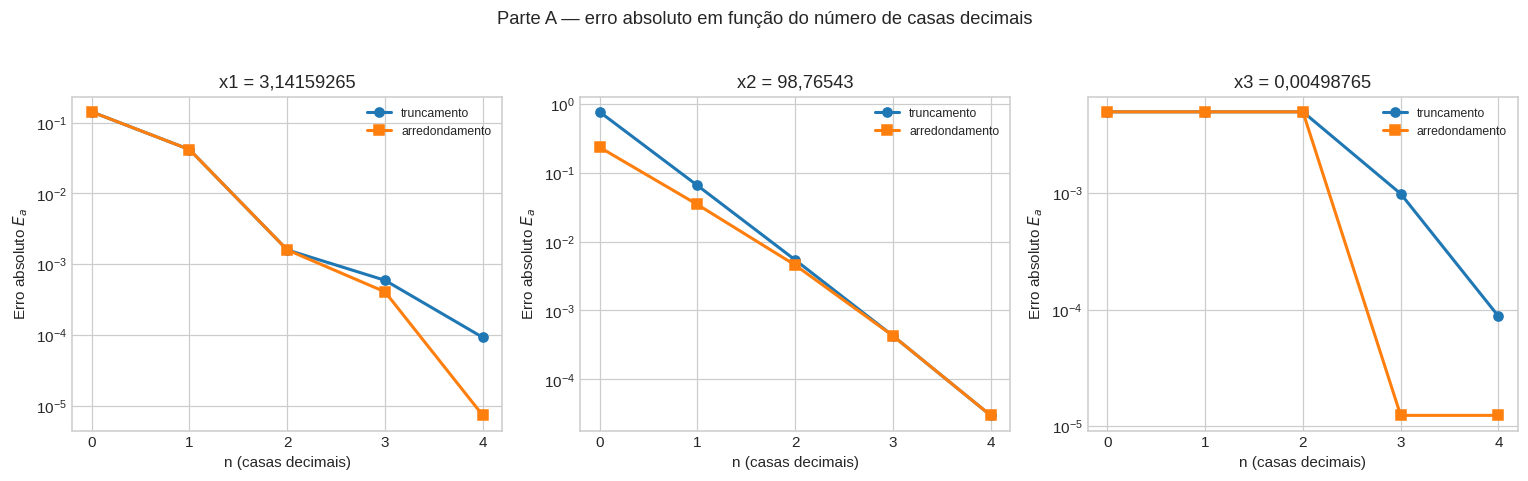

In [ ]:
# Cria uma figura com três painéis lado a lado, um para cada valor de referência.
figura, eixos = plt.subplots(1, 3, figsize=(14, 4.2))

# Percorre simultaneamente os painéis e os nomes dos valores.
for eixo, nome in zip(eixos, valores_parte_a.keys()):
    # Seleciona apenas as linhas da tabela referentes a este valor.
    recorte = tabela_parte_a[tabela_parte_a["valor"] == nome]

    # Percorre os dois métodos de aproximação.
    for metodo, marcador in [("truncamento", "o"), ("arredondamento", "s")]:
        # Seleciona as linhas do método atual.
        sub = recorte[recorte["método"] == metodo]

        # Substitui eventuais erros nulos por nan para não quebrar a escala log.
        erros = sub["Ea"].replace(0.0, np.nan)

        # Desenha a curva do erro absoluto em função do número de casas.
        eixo.plot(sub["n (casas)"], erros, marker=marcador, linewidth=2, label=metodo)

    # Aplica escala logarítmica ao eixo vertical.
    eixo.set_yscale("log")

    # Identifica o eixo horizontal.
    eixo.set_xlabel("n (casas decimais)")

    # Identifica o eixo vertical.
    eixo.set_ylabel("Erro absoluto $E_a$")

    # Usa apenas valores inteiros de n no eixo horizontal.
    eixo.set_xticks(casas_testadas)

    # Adiciona o título do painel.
    eixo.set_title(nome)

    # Exibe a legenda do painel.
    eixo.legend(fontsize=8)

# Ajusta o espaçamento entre os painéis.
figura.suptitle("Parte A — erro absoluto em função do número de casas decimais", y=1.03)

# Organiza o layout para evitar sobreposição de rótulos.
plt.tight_layout()

# Mostra a figura na saída da célula.
plt.show()

**Código A5**

In [ ]:
# Cria uma tabela comparando o erro absoluto dos dois métodos lado a lado.
comparacao = tabela_parte_a.pivot_table(
    index=["valor", "n (casas)"], columns="método", values="Ea"
)

# Cria uma coluna que informa se o arredondamento foi melhor ou igual ao truncamento.
comparacao["arredondamento <= truncamento"] = (
    comparacao["arredondamento"] <= comparacao["truncamento"]
)

# Exibe a tabela de comparação.
display(comparacao.style.format({"arredondamento": "{:.3e}", "truncamento": "{:.3e}"}))

# Verifica se a propriedade se confirmou em todos os quinze casos analisados.
print(
    "A desigualdade se confirmou em todos os casos?",
    bool(comparacao["arredondamento <= truncamento"].all()),
)

A desigualdade se confirmou em todos os casos? True


## 4. Parte B — medidas de pressão arterial

Dez medidas consecutivas de pressão arterial sistólica, em mmHg. O valor de referência
é a média calculada com **todos** os algarismos disponíveis.

> Conforme o enunciado, nenhuma interpretação médica dos valores é feita: o interesse
> aqui é exclusivamente o efeito da representação numérica sobre média e variabilidade.

In [ ]:
# Armazena as dez medidas originais em um vetor NumPy.
medidas = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)

# Cria a série arredondada para o inteiro mais próximo.
medidas_arred_int = np.array([round(valor, 0) for valor in medidas])

# Cria a série truncada para números inteiros.
medidas_trunc_int = np.array([truncar(valor, 0) for valor in medidas])

# Cria a série arredondada para uma casa decimal.
medidas_arred_1 = np.array([round(valor, 1) for valor in medidas])

# Organiza as quatro séries em um dicionário para facilitar os laços seguintes.
series = {
    "originais": medidas,
    "arredondados (inteiro)": medidas_arred_int,
    "truncados (inteiro)": medidas_trunc_int,
    "arredondados (1 casa)": medidas_arred_1,
}

# Define a média de referência, calculada com todos os algarismos disponíveis.
media_referencia = medidas.mean()

# Exibe a média de referência com muitas casas decimais.
print(f"Média de referência = {media_referencia:.12f} mmHg")

Média de referência = 121.120000000000 mmHg


### B.1 — Estatísticas descritivas e erros da média

In [ ]:
# Cria uma lista para acumular as estatísticas de cada série.
linhas_parte_b = []

# Percorre cada uma das quatro séries.
for nome, valores in series.items():
    # Calcula os três erros da média da série em relação à média de referência.
    ea, er, ep = calcular_erros(media_referencia, valores.mean())

    # Armazena as estatísticas descritivas e os erros da média.
    linhas_parte_b.append(
        {
            "série": nome,
            "média (mmHg)": valores.mean(),
            "mínimo (mmHg)": valores.min(),
            "máximo (mmHg)": valores.max(),
            "amplitude (mmHg)": valores.max() - valores.min(),
            "desvio-padrão amostral (mmHg)": valores.std(ddof=1),
            "Ea da média (mmHg)": ea,
            "Er da média": er,
            "E% da média (%)": ep,
        }
    )

# Converte a lista em uma tabela do pandas.
tabela_parte_b = pd.DataFrame(linhas_parte_b).set_index("série")

# Exibe a tabela formatada.
display(
    tabela_parte_b.style.format(
        {
            "média (mmHg)": "{:.4f}",
            "mínimo (mmHg)": "{:.1f}",
            "máximo (mmHg)": "{:.1f}",
            "amplitude (mmHg)": "{:.1f}",
            "desvio-padrão amostral (mmHg)": "{:.4f}",
            "Ea da média (mmHg)": "{:.6f}",
            "Er da média": "{:.3e}",
            "E% da média (%)": "{:.4f}",
        }
    )
)

,média (mmHg),mínimo (mmHg),máximo (mmHg),amplitude (mmHg),desvio-padrão amostral (mmHg),Ea da média (mmHg),Er da média,E% da média (%)
série,,,,,,,,
originais,121.1200,119.8,122.4,2.6,0.8337,0.000000,0.000e+00,0.0000
arredondados (inteiro),121.1000,120.0,122.0,2.0,0.8756,0.020000,1.651e-04,0.0165
truncados (inteiro),120.7000,119.0,122.0,3.0,0.9487,0.420000,3.468e-03,0.3468
arredondados (1 casa),121.1200,119.8,122.4,2.6,0.8337,0.000000,0.000e+00,0.0000


### B.2 — Gráficos obrigatórios

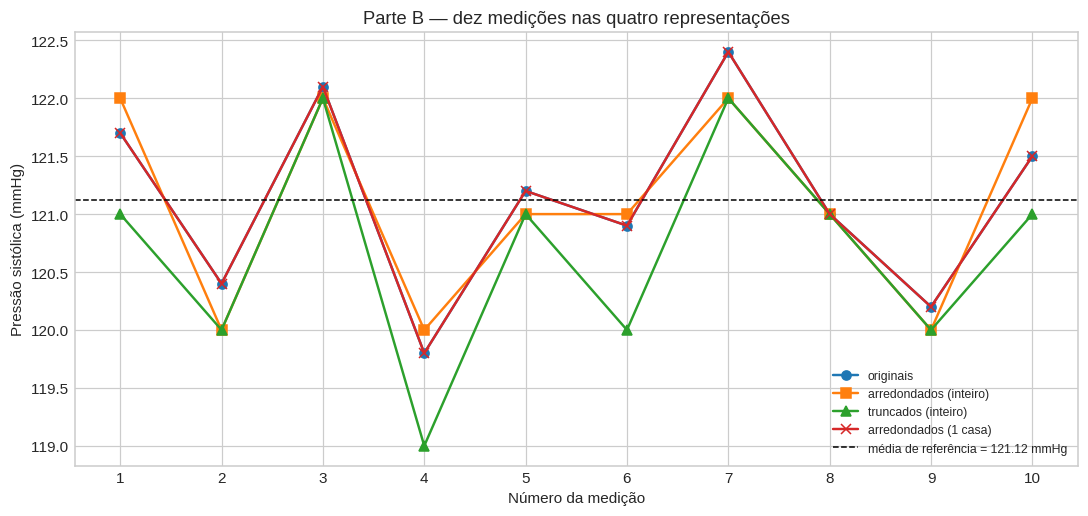

In [ ]:
# Cria a figura das dez medições com as quatro séries sobrepostas.
plt.figure(figsize=(10, 4.8))

# Cria o vetor com os índices das medições, de 1 a 10.
indices = np.arange(1, len(medidas) + 1)

# Define marcadores diferentes para cada série.
marcadores = ["o", "s", "^", "x"]

# Percorre as séries e os marcadores simultaneamente.
for (nome, valores), marcador in zip(series.items(), marcadores):
    # Desenha a série atual.
    plt.plot(indices, valores, marker=marcador, linewidth=1.6, label=nome)

# Desenha a linha horizontal da média de referência.
plt.axhline(
    media_referencia,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label=f"média de referência = {media_referencia:.2f} mmHg",
)

# Identifica o eixo horizontal.
plt.xlabel("Número da medição")

# Identifica o eixo vertical.
plt.ylabel("Pressão sistólica (mmHg)")

# Usa apenas valores inteiros no eixo horizontal.
plt.xticks(indices)

# Adiciona o título do gráfico.
plt.title("Parte B — dez medições nas quatro representações")

# Exibe a legenda fora da área do gráfico.
plt.legend(fontsize=8, loc="lower right")

# Organiza o layout.
plt.tight_layout()

# Mostra a figura.
plt.show()

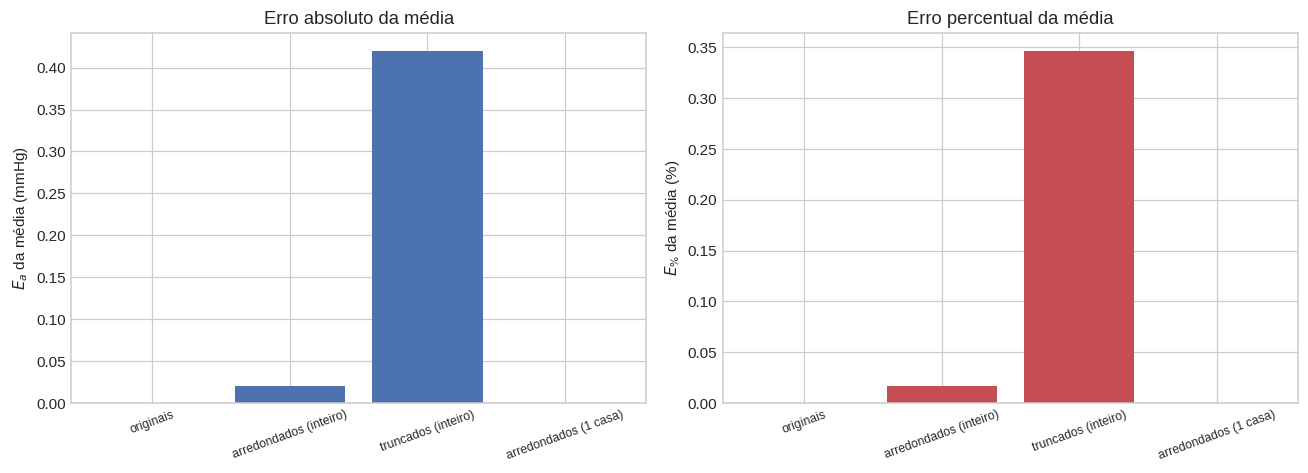

In [ ]:
# Cria uma figura com dois painéis para os gráficos de barras dos erros.
figura, eixos = plt.subplots(1, 2, figsize=(12, 4.4))

# Recupera os nomes das séries para usar como rótulos das barras.
nomes_series = list(tabela_parte_b.index)

# Desenha o gráfico de barras dos erros absolutos das médias.
eixos[0].bar(nomes_series, tabela_parte_b["Ea da média (mmHg)"], color="#4C72B0")

# Identifica o eixo vertical do primeiro painel.
eixos[0].set_ylabel("$E_a$ da média (mmHg)")

# Adiciona o título do primeiro painel.
eixos[0].set_title("Erro absoluto da média")

# Desenha o gráfico de barras dos erros percentuais das médias.
eixos[1].bar(nomes_series, tabela_parte_b["E% da média (%)"], color="#C44E52")

# Identifica o eixo vertical do segundo painel.
eixos[1].set_ylabel("$E_\\%$ da média (%)")

# Adiciona o título do segundo painel.
eixos[1].set_title("Erro percentual da média")

# Percorre os dois painéis para ajustar os rótulos do eixo horizontal.
for eixo in eixos:
    # Gira os rótulos para que não se sobreponham.
    eixo.tick_params(axis="x", rotation=20, labelsize=8)

# Organiza o layout.
plt.tight_layout()

# Mostra a figura.
plt.show()

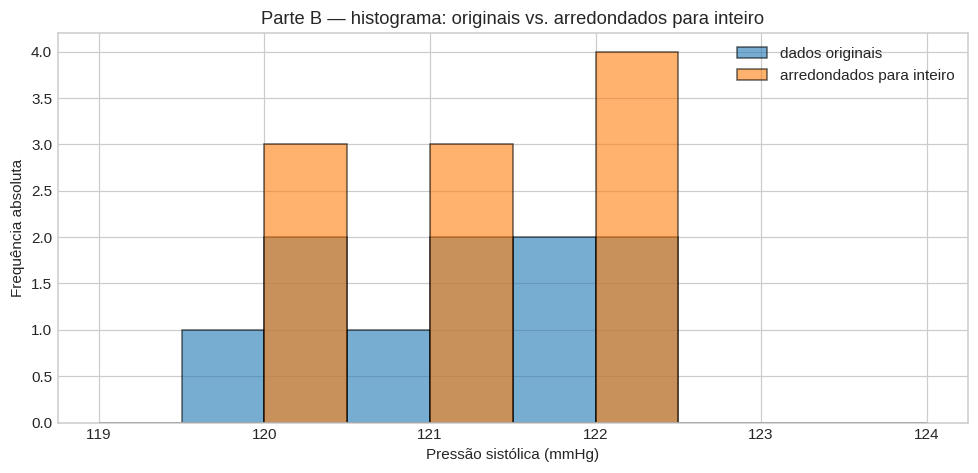

In [ ]:
# Cria a figura do histograma comparativo.
plt.figure(figsize=(9, 4.4))

# Define as bordas das classes do histograma, com largura de 1 mmHg.
bordas = np.arange(119.0, 124.0 + 0.5, 0.5)

# Desenha o histograma dos dados originais.
plt.hist(medidas, bins=bordas, alpha=0.6, label="dados originais", edgecolor="black")

# Desenha o histograma dos dados arredondados para inteiro.
plt.hist(
    medidas_arred_int,
    bins=bordas,
    alpha=0.6,
    label="arredondados para inteiro",
    edgecolor="black",
)

# Identifica o eixo horizontal.
plt.xlabel("Pressão sistólica (mmHg)")

# Identifica o eixo vertical.
plt.ylabel("Frequência absoluta")

# Adiciona o título do gráfico.
plt.title("Parte B — histograma: originais vs. arredondados para inteiro")

# Exibe a legenda.
plt.legend()

# Organiza o layout.
plt.tight_layout()

# Mostra a figura.
plt.show()

**Código B3**

In [ ]:
# Compara diretamente o desvio-padrão das séries em relação ao das medidas originais.
for nome, valores in series.items():
    # Calcula os erros do desvio-padrão amostral em relação ao valor de referência.
    ea, er, ep = calcular_erros(medidas.std(ddof=1), valores.std(ddof=1))

    # Exibe o desvio-padrão da série e o erro percentual correspondente.
    print(f"{nome:<24} s = {valores.std(ddof=1):.4f} mmHg | E% = {ep:.3f}%")

originais                s = 0.8337 mmHg | E% = 0.000%
arredondados (inteiro)   s = 0.8756 mmHg | E% = 5.021%
truncados (inteiro)      s = 0.9487 mmHg | E% = 13.787%
arredondados (1 casa)    s = 0.8337 mmHg | E% = 0.000%


## 5. Parte C — vazão em um tubo de pequeno diâmetro

Para escoamento laminar idealizado, a relação de Hagen–Poiseuille fornece

$$Q = \frac{\pi r^{4} \Delta p}{8 \mu L}.$$

Valores adotados:

$$r = 0{,}80\ \text{mm}, \quad L = 0{,}20\ \text{m}, \quad
\mu = 3{,}5\times10^{-3}\ \text{Pa}\cdot\text{s}, \quad \Delta p = 1200\ \text{Pa}.$$

**Atenção às unidades:** o raio é dado em milímetros e precisa ser convertido para
metros antes de entrar na fórmula, caso contrário o resultado erra por um fator $10^{12}$.

In [ ]:
# Define a função que calcula a vazão pela relação de Hagen-Poiseuille.
def vazao_hp(raio_m, delta_p, mu, comprimento):
    # Calcula o numerador da expressão, proporcional à quarta potência do raio.
    numerador = math.pi * raio_m ** 4 * delta_p

    # Calcula o denominador da expressão.
    denominador = 8.0 * mu * comprimento

    # Devolve a vazão em metros cúbicos por segundo.
    return numerador / denominador


# Define o raio de referência em milímetros.
r_mm = 0.80

# Define o comprimento do tubo em metros.
L_c = 0.20

# Define a viscosidade dinâmica em pascal segundo.
mu_c = 3.5e-3

# Define a diferença de pressão em pascal.
dp_c = 1200.0

# Calcula a vazão de referência convertendo o raio de milímetros para metros.
Q_ref_c = vazao_hp(r_mm * 1e-3, dp_c, mu_c, L_c)

# Exibe a vazão de referência em metros cúbicos por segundo.
print(f"Q de referência = {Q_ref_c:.10e} m³/s")

# Exibe a mesma vazão convertida para mililitros por minuto, mais intuitiva.
print(f"Q de referência = {Q_ref_c * 1e6 * 60:.6f} mL/min")

Q de referência = 2.7574207520e-07 m³/s
Q de referência = 16.544525 mL/min


### C.1 — Precisão das variáveis

Cada cenário aplica uma aproximação diferente às variáveis de entrada e recalcula $Q$.

In [ ]:
# Calcula as versões aproximadas do raio, em milímetros, com uma casa decimal.
r_arred = round(r_mm, 1)
r_trunc = truncar(r_mm, 1)

# Calcula as versões aproximadas da viscosidade com três casas decimais.
mu_arred = round(mu_c, 3)
mu_trunc = truncar(mu_c, 3)

# Calcula as versões aproximadas da pressão em centenas de pascal.
dp_arred = float(round(dp_c, -2))
dp_trunc = truncar(dp_c, -2)

# Monta a lista de cenários exigidos pelo enunciado.
cenarios = [
    ("1. todos os valores fornecidos", r_mm, dp_c, mu_c),
    ("2a. r arredondado (1 casa, mm)", r_arred, dp_c, mu_c),
    ("2b. r truncado (1 casa, mm)", r_trunc, dp_c, mu_c),
    ("3a. mu arredondada (3 casas)", r_mm, dp_c, mu_arred),
    ("3b. mu truncada (3 casas)", r_mm, dp_c, mu_trunc),
    ("4a. dp arredondada (centenas)", r_mm, dp_arred, mu_c),
    ("4b. dp truncada (centenas)", r_mm, dp_trunc, mu_c),
    ("5a. todas arredondadas", r_arred, dp_arred, mu_arred),
    ("5b. todas truncadas", r_trunc, dp_trunc, mu_trunc),
]

# Cria uma lista para acumular as linhas da tabela da Parte C.
linhas_parte_c = []

# Percorre cada cenário definido acima.
for descricao, raio, pressao, viscosidade in cenarios:
    # Calcula a vazão do cenário atual.
    Q_cenario = vazao_hp(raio * 1e-3, pressao, viscosidade, L_c)

    # Calcula os três erros em relação à vazão de referência.
    ea, er, ep = calcular_erros(Q_ref_c, Q_cenario)

    # Armazena a linha correspondente ao cenário.
    linhas_parte_c.append(
        {
            "cenário": descricao,
            "r (mm)": raio,
            "Δp (Pa)": pressao,
            "μ (Pa·s)": viscosidade,
            "Q (m³/s)": Q_cenario,
            "Q (mL/min)": Q_cenario * 1e6 * 60,
            "Ea (m³/s)": ea,
            "Er": er,
            "E% (%)": ep,
        }
    )

# Converte a lista em uma tabela do pandas.
tabela_parte_c = pd.DataFrame(linhas_parte_c).set_index("cenário")

# Exibe a tabela formatada.
display(
    tabela_parte_c.style.format(
        {
            "r (mm)": "{:.4f}",
            "Δp (Pa)": "{:.1f}",
            "μ (Pa·s)": "{:.6f}",
            "Q (m³/s)": "{:.6e}",
            "Q (mL/min)": "{:.5f}",
            "Ea (m³/s)": "{:.4e}",
            "Er": "{:.4e}",
            "E% (%)": "{:.4f}",
        }
    )
)

,r (mm),Δp (Pa),μ (Pa·s),Q (m³/s),Q (mL/min),Ea (m³/s),Er,E% (%)
cenário,,,,,,,,
1. todos os valores fornecidos,0.8000,1200.0,0.003500,2.757421e-07,16.54452,0.0000e+00,0.0000e+00,0.0000
"2a. r arredondado (1 casa, mm)",0.8000,1200.0,0.003500,2.757421e-07,16.54452,0.0000e+00,0.0000e+00,0.0000
"2b. r truncado (1 casa, mm)",0.8000,1200.0,0.003500,2.757421e-07,16.54452,0.0000e+00,0.0000e+00,0.0000
3a. mu arredondada (3 casas),0.8000,1200.0,0.004000,2.412743e-07,14.47646,3.4468e-08,1.2500e-01,12.5000
3b. mu truncada (3 casas),0.8000,1200.0,0.003000,3.216991e-07,19.30195,4.5957e-08,1.6667e-01,16.6667
4a. dp arredondada (centenas),0.8000,1200.0,0.003500,2.757421e-07,16.54452,0.0000e+00,0.0000e+00,0.0000
4b. dp truncada (centenas),0.8000,1200.0,0.003500,2.757421e-07,16.54452,0.0000e+00,0.0000e+00,0.0000
5a. todas arredondadas,0.8000,1200.0,0.004000,2.412743e-07,14.47646,3.4468e-08,1.2500e-01,12.5000
5b. todas truncadas,0.8000,1200.0,0.003000,3.216991e-07,19.30195,4.5957e-08,1.6667e-01,16.6667


**Leitura crítica da tabela — três observações que o próprio cálculo revela:**

1. **$r$ e $\Delta p$ produzem erro exatamente nulo.** O valor $r = 0{,}80$ mm já possui
   uma casa decimal significativa ($0{,}8$), e $\Delta p = 1200$ Pa já é um múltiplo
   exato de 100. Arredondar ou truncar **não altera nada**. Aproximação só introduz erro
   quando existe informação a ser descartada.

2. **Toda a diferença vem de $\mu$.** Arredondar $0{,}0035$ para três casas dá $0{,}004$
   e truncar dá $0{,}003$. Como $Q \propto 1/\mu$, os erros relativos resultantes são de
   aproximadamente $12{,}5\%$ e $16{,}7\%$ — enormes para uma mudança de apenas um
   algarismo. O motivo: $0{,}0035$ tem só dois algarismos significativos, e cortar na
   terceira casa decimal destrói metade da informação disponível.

3. **O cenário combinado reproduz o cenário de $\mu$.** Como os outros dois são neutros,
   o erro total é governado pela variável mais mal representada. Em propagação de erros,
   a variável com menos algarismos significativos domina o resultado.

### C.2 — Sensibilidade ao raio

O raio varia de $0{,}70$ a $0{,}90$ mm. Para cada raio comparamos $Q$ de referência,
$Q$ com o raio arredondado para uma casa decimal e $Q$ com o raio truncado.

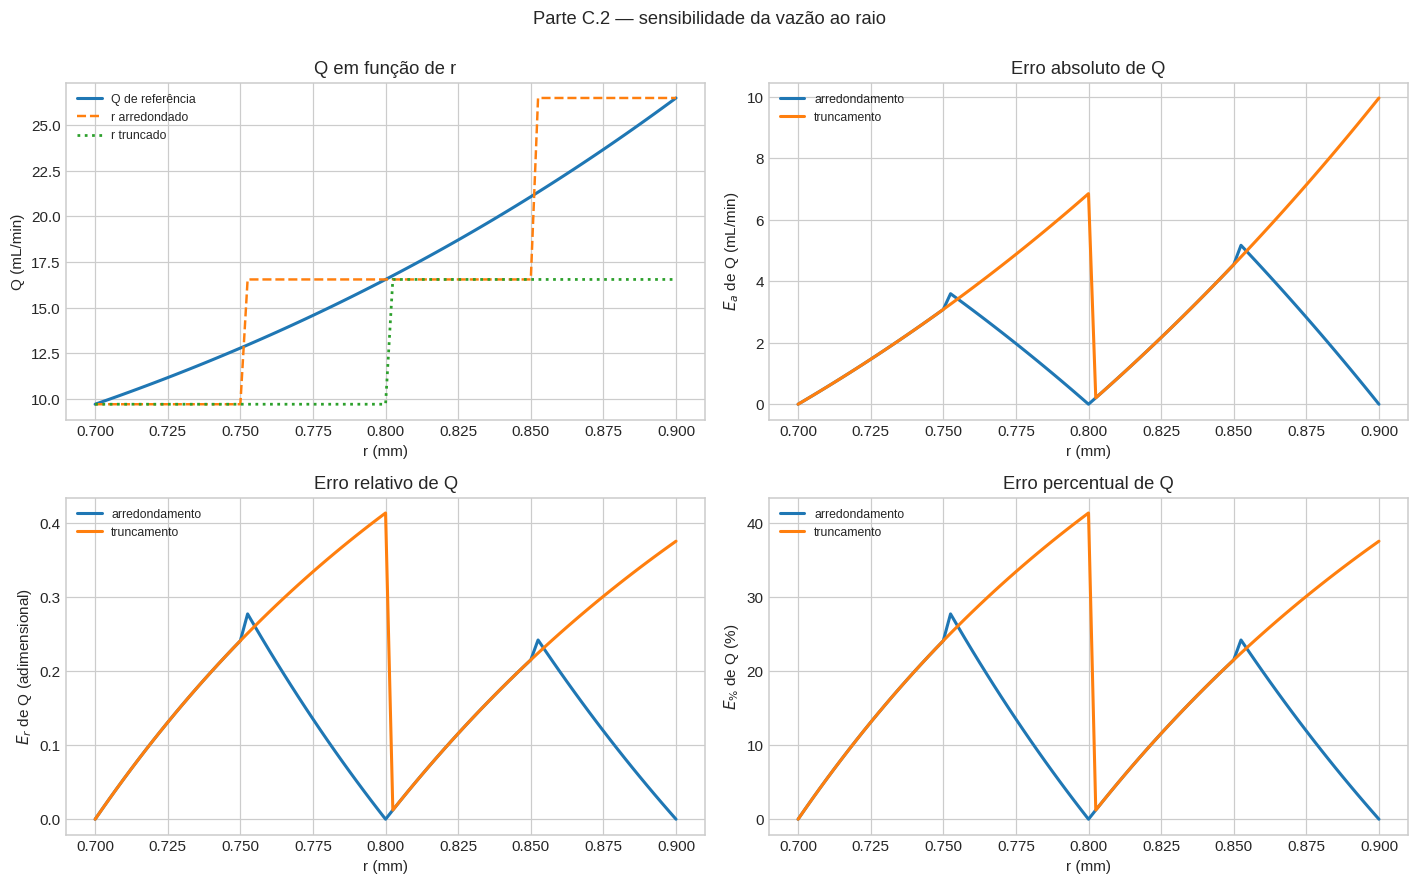

Erro percentual máximo com arredondamento: 27.74%
Erro percentual máximo com truncamento:    41.38%


In [ ]:
# Cria o vetor de raios entre 0,70 e 0,90 mm com passo de 0,0025 mm.
raios_mm = np.arange(0.70, 0.90 + 1e-9, 0.0025)

# Calcula a vazão de referência para cada raio do vetor.
Q_ref_vetor = np.array([vazao_hp(r * 1e-3, dp_c, mu_c, L_c) for r in raios_mm])

# Calcula a vazão usando o raio arredondado para uma casa decimal.
Q_arred_vetor = np.array(
    [vazao_hp(round(r, 1) * 1e-3, dp_c, mu_c, L_c) for r in raios_mm]
)

# Calcula a vazão usando o raio truncado para uma casa decimal.
Q_trunc_vetor = np.array(
    [vazao_hp(truncar(r, 1) * 1e-3, dp_c, mu_c, L_c) for r in raios_mm]
)

# Calcula os erros absolutos das duas aproximações.
ea_arred = np.abs(Q_ref_vetor - Q_arred_vetor)
ea_trunc = np.abs(Q_ref_vetor - Q_trunc_vetor)

# Calcula os erros relativos das duas aproximações.
er_arred = ea_arred / np.abs(Q_ref_vetor)
er_trunc = ea_trunc / np.abs(Q_ref_vetor)

# Cria uma figura com quatro painéis organizados em duas linhas.
figura, eixos = plt.subplots(2, 2, figsize=(13, 8))

# Desenha o gráfico de Q em função de r no primeiro painel.
eixos[0, 0].plot(raios_mm, Q_ref_vetor * 1e6 * 60, linewidth=2, label="Q de referência")
eixos[0, 0].plot(raios_mm, Q_arred_vetor * 1e6 * 60, "--", linewidth=1.6, label="r arredondado")
eixos[0, 0].plot(raios_mm, Q_trunc_vetor * 1e6 * 60, ":", linewidth=1.8, label="r truncado")
eixos[0, 0].set_xlabel("r (mm)")
eixos[0, 0].set_ylabel("Q (mL/min)")
eixos[0, 0].set_title("Q em função de r")
eixos[0, 0].legend(fontsize=8)

# Desenha o gráfico do erro absoluto no segundo painel.
eixos[0, 1].plot(raios_mm, ea_arred * 1e6 * 60, linewidth=2, label="arredondamento")
eixos[0, 1].plot(raios_mm, ea_trunc * 1e6 * 60, linewidth=2, label="truncamento")
eixos[0, 1].set_xlabel("r (mm)")
eixos[0, 1].set_ylabel("$E_a$ de Q (mL/min)")
eixos[0, 1].set_title("Erro absoluto de Q")
eixos[0, 1].legend(fontsize=8)

# Desenha o gráfico do erro relativo no terceiro painel.
eixos[1, 0].plot(raios_mm, er_arred, linewidth=2, label="arredondamento")
eixos[1, 0].plot(raios_mm, er_trunc, linewidth=2, label="truncamento")
eixos[1, 0].set_xlabel("r (mm)")
eixos[1, 0].set_ylabel("$E_r$ de Q (adimensional)")
eixos[1, 0].set_title("Erro relativo de Q")
eixos[1, 0].legend(fontsize=8)

# Desenha o gráfico do erro percentual no quarto painel.
eixos[1, 1].plot(raios_mm, 100 * er_arred, linewidth=2, label="arredondamento")
eixos[1, 1].plot(raios_mm, 100 * er_trunc, linewidth=2, label="truncamento")
eixos[1, 1].set_xlabel("r (mm)")
eixos[1, 1].set_ylabel("$E_\\%$ de Q (%)")
eixos[1, 1].set_title("Erro percentual de Q")
eixos[1, 1].legend(fontsize=8)

# Adiciona um título geral à figura.
figura.suptitle("Parte C.2 — sensibilidade da vazão ao raio", y=1.0)

# Organiza o layout.
plt.tight_layout()

# Mostra a figura.
plt.show()

# Exibe o erro percentual máximo observado em cada método.
print(f"Erro percentual máximo com arredondamento: {100 * er_arred.max():.2f}%")
print(f"Erro percentual máximo com truncamento:    {100 * er_trunc.max():.2f}%")

## 6. Parte D — escoamento em um nanocateter

Modelo didático de nanocateter cilíndrico:

$$r = 50\ \text{nm}, \quad L = 10\ \mu\text{m}, \quad
\mu = 3{,}5\times10^{-3}\ \text{Pa}\cdot\text{s}, \quad \Delta p = 5000\ \text{Pa}.$$

In [ ]:
# Define o raio do nanocateter em metros (50 nanômetros).
r_nano = 50e-9

# Define o comprimento do nanocateter em metros (10 micrômetros).
L_nano = 10e-6

# Define a viscosidade dinâmica em pascal segundo.
mu_nano = 3.5e-3

# Define a diferença de pressão em pascal.
dp_nano = 5000.0

# Calcula a vazão de referência do nanocateter.
Q_ref_nano = vazao_hp(r_nano, dp_nano, mu_nano, L_nano)

# Exibe a vazão em metros cúbicos por segundo.
print(f"Q(50 nm) = {Q_ref_nano:.10e} m³/s")

# Exibe a mesma vazão em femtolitros por segundo, unidade mais legível nessa escala.
print(f"Q(50 nm) = {Q_ref_nano * 1e18:.6f} fL/s")

# Exibe quanto tempo levaria para escoar um picolitro de fluido.
print(f"Tempo para escoar 1 pL = {1e-15 / Q_ref_nano / 3600:.2f} horas")

Q(50 nm) = 3.5062418009e-19 m³/s
Q(50 nm) = 0.350624 fL/s
Tempo para escoar 1 pL = 0.79 horas


### D.1 — Erro geométrico

Consideramos erros no raio de $\Delta r = 0{,}1;\ 0{,}2;\ \ldots;\ 5{,}0$ nm e calculamos
as vazões associadas a $r_- = r - \Delta r$ e $r_+ = r + \Delta r$.

In [ ]:
# Cria o vetor de erros no raio, de 0,1 a 5,0 nm com passo de 0,1 nm.
delta_r_nm = np.arange(0.1, 5.0 + 1e-9, 0.1)

# Converte os erros do raio para metros.
delta_r_m = delta_r_nm * 1e-9

# Calcula o raio reduzido para cada valor de erro.
r_menos = r_nano - delta_r_m

# Calcula o raio aumentado para cada valor de erro.
r_mais = r_nano + delta_r_m

# Calcula a vazão associada ao raio reduzido.
Q_menos = np.array([vazao_hp(r, dp_nano, mu_nano, L_nano) for r in r_menos])

# Calcula a vazão associada ao raio aumentado.
Q_mais = np.array([vazao_hp(r, dp_nano, mu_nano, L_nano) for r in r_mais])

# Calcula o erro absoluto máximo entre os dois desvios possíveis.
ea_max_nano = np.maximum(np.abs(Q_mais - Q_ref_nano), np.abs(Q_menos - Q_ref_nano))

# Calcula o erro relativo máximo.
er_max_nano = ea_max_nano / abs(Q_ref_nano)

# Calcula o erro percentual máximo.
ep_max_nano = 100.0 * er_max_nano

# Calcula a estimativa linear do erro relativo, dada pela aproximação de primeira ordem.
er_linear = 4.0 * delta_r_m / r_nano

# Monta uma tabela com uma amostra dos resultados, a cada 0,5 nm.
tabela_parte_d = pd.DataFrame(
    {
        "Δr (nm)": delta_r_nm,
        "Q(r-) (fL/s)": Q_menos * 1e18,
        "Q(r+) (fL/s)": Q_mais * 1e18,
        "Ea máx (fL/s)": ea_max_nano * 1e18,
        "Er máx": er_max_nano,
        "E% máx (%)": ep_max_nano,
        "4·Δr/r (%)": 100 * er_linear,
    }
)

# Exibe apenas as linhas múltiplas de 0,5 nm para manter a tabela legível.
display(
    tabela_parte_d.iloc[4::5]
    .style.format(
        {
            "Δr (nm)": "{:.1f}",
            "Q(r-) (fL/s)": "{:.4f}",
            "Q(r+) (fL/s)": "{:.4f}",
            "Ea máx (fL/s)": "{:.4f}",
            "Er máx": "{:.4f}",
            "E% máx (%)": "{:.2f}",
            "4·Δr/r (%)": "{:.2f}",
        }
    )
    .hide(axis="index")
)

Δr (nm),Q(r-) (fL/s),Q(r+) (fL/s),Ea máx (fL/s),Er máx,E% máx (%),4·Δr/r (%)
0.5,0.3368,0.3649,0.0142,0.0406,4.06,4.00
1.0,0.3234,0.3795,0.0289,0.0824,8.24,8.00
1.5,0.3104,0.3946,0.0440,0.1255,12.55,12.00
2.0,0.2978,0.4102,0.0596,0.1699,16.99,16.00
2.5,0.2856,0.4262,0.0756,0.2155,21.55,20.00
3.0,0.2737,0.4427,0.0920,0.2625,26.25,24.00
3.5,0.2623,0.4596,0.1090,0.3108,31.08,28.00
4.0,0.2512,0.4770,0.1264,0.3605,36.05,32.00
4.5,0.2404,0.4949,0.1443,0.4116,41.16,36.00
5.0,0.2300,0.5133,0.1627,0.4641,46.41,40.00


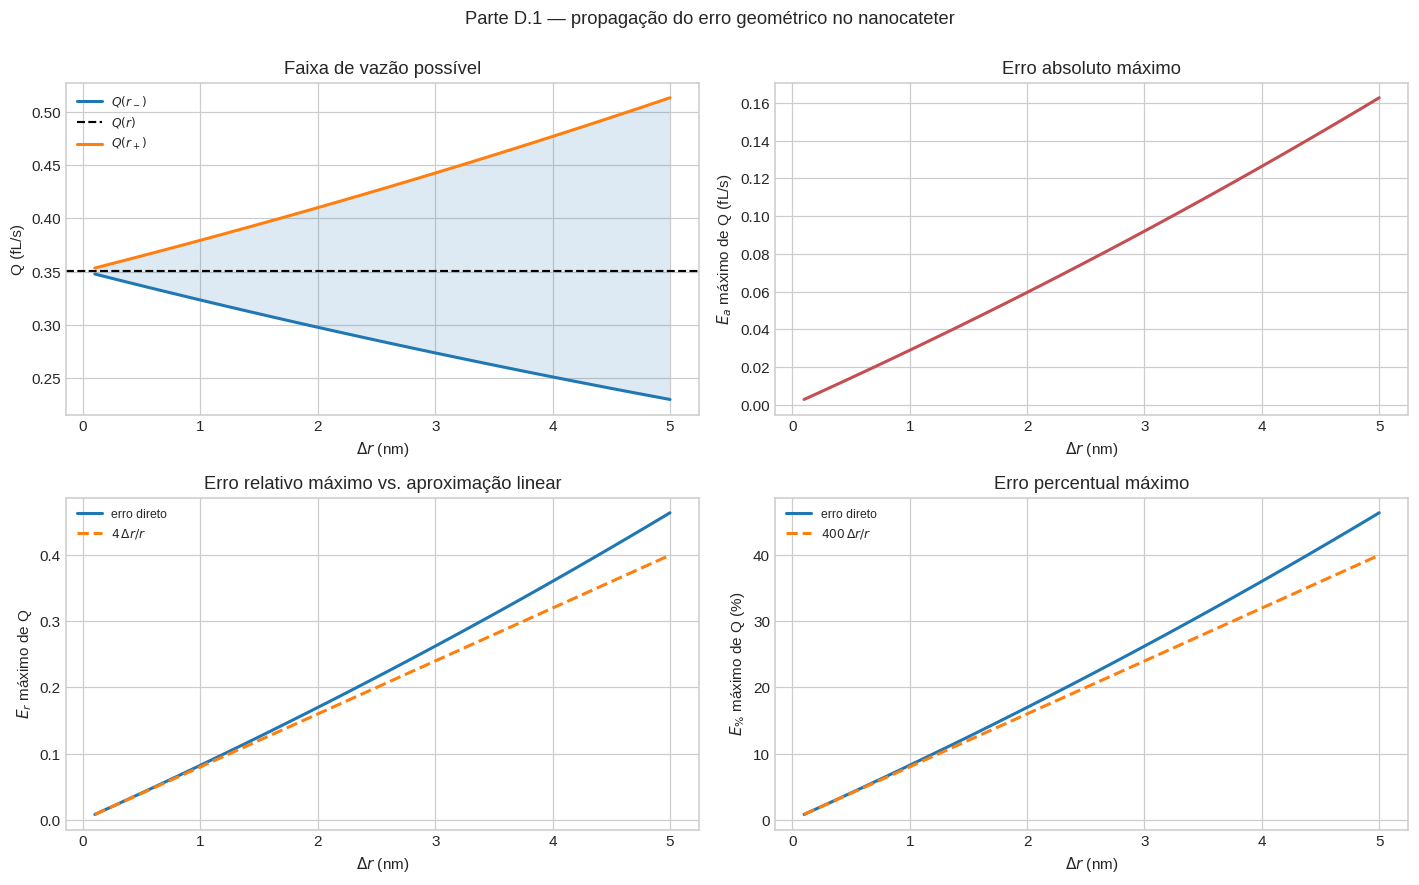

In [ ]:
# Cria uma figura com quatro painéis organizados em duas linhas.
figura, eixos = plt.subplots(2, 2, figsize=(13, 8))

# Desenha as três curvas de vazão no primeiro painel.
eixos[0, 0].plot(delta_r_nm, Q_menos * 1e18, linewidth=2, label="$Q(r_-)$")
eixos[0, 0].axhline(Q_ref_nano * 1e18, color="black", linestyle="--", linewidth=1.4, label="$Q(r)$")
eixos[0, 0].plot(delta_r_nm, Q_mais * 1e18, linewidth=2, label="$Q(r_+)$")
eixos[0, 0].fill_between(delta_r_nm, Q_menos * 1e18, Q_mais * 1e18, alpha=0.15)
eixos[0, 0].set_xlabel("$\\Delta r$ (nm)")
eixos[0, 0].set_ylabel("Q (fL/s)")
eixos[0, 0].set_title("Faixa de vazão possível")
eixos[0, 0].legend(fontsize=8)

# Desenha o erro absoluto máximo no segundo painel.
eixos[0, 1].plot(delta_r_nm, ea_max_nano * 1e18, linewidth=2, color="#C44E52")
eixos[0, 1].set_xlabel("$\\Delta r$ (nm)")
eixos[0, 1].set_ylabel("$E_a$ máximo de Q (fL/s)")
eixos[0, 1].set_title("Erro absoluto máximo")

# Desenha o erro relativo máximo no terceiro painel, junto com a aproximação linear.
eixos[1, 0].plot(delta_r_nm, er_max_nano, linewidth=2, label="erro direto")
eixos[1, 0].plot(delta_r_nm, er_linear, "--", linewidth=2, label="$4\\,\\Delta r/r$")
eixos[1, 0].set_xlabel("$\\Delta r$ (nm)")
eixos[1, 0].set_ylabel("$E_r$ máximo de Q")
eixos[1, 0].set_title("Erro relativo máximo vs. aproximação linear")
eixos[1, 0].legend(fontsize=8)

# Desenha o erro percentual máximo no quarto painel.
eixos[1, 1].plot(delta_r_nm, ep_max_nano, linewidth=2, label="erro direto")
eixos[1, 1].plot(delta_r_nm, 100 * er_linear, "--", linewidth=2, label="$400\\,\\Delta r/r$")
eixos[1, 1].set_xlabel("$\\Delta r$ (nm)")
eixos[1, 1].set_ylabel("$E_\\%$ máximo de Q (%)")
eixos[1, 1].set_title("Erro percentual máximo")
eixos[1, 1].legend(fontsize=8)

# Adiciona um título geral à figura.
figura.suptitle("Parte D.1 — propagação do erro geométrico no nanocateter", y=1.0)

# Organiza o layout.
plt.tight_layout()

# Mostra a figura.
plt.show()

### Comparação com a aproximação linear

A aproximação de primeira ordem prevê

$$\frac{\Delta Q}{Q} \approx 4\,\frac{\Delta r}{r},$$

enquanto o valor exato para $r_+$ é

$$\frac{\Delta Q}{Q} = \left(1 + \frac{\Delta r}{r}\right)^{4} - 1
= 4t + 6t^{2} + 4t^{3} + t^{4}, \qquad t = \frac{\Delta r}{r}.$$

A diferença entre as duas expressões é $6t^{2} + 4t^{3} + t^{4}$: **desprezível para $t$
pequeno e crescente para $t$ grande**. A célula abaixo quantifica isso.

In [ ]:
# Calcula o erro exato para o raio aumentado.
er_exato_mais = (Q_mais - Q_ref_nano) / Q_ref_nano

# Calcula a discrepância entre o modelo linear e o cálculo exato.
discrepancia = np.abs(er_exato_mais - er_linear) / er_exato_mais

# Percorre alguns valores representativos de delta r.
for indice in [0, 4, 9, 24, 49]:
    # Exibe a comparação entre o erro exato e a estimativa linear.
    print(
        f"Δr = {delta_r_nm[indice]:.1f} nm (t = {delta_r_m[indice]/r_nano:.3f}) | "
        f"exato = {100*er_exato_mais[indice]:6.2f}% | "
        f"linear = {100*er_linear[indice]:6.2f}% | "
        f"subestimativa da linear = {100*discrepancia[indice]:.2f}%"
    )

Δr = 0.1 nm (t = 0.002) | exato =   0.80% | linear =   0.80% | subestimativa da linear = 0.30%
Δr = 0.5 nm (t = 0.010) | exato =   4.06% | linear =   4.00% | subestimativa da linear = 1.49%
Δr = 1.0 nm (t = 0.020) | exato =   8.24% | linear =   8.00% | subestimativa da linear = 2.95%
Δr = 2.5 nm (t = 0.050) | exato =  21.55% | linear =  20.00% | subestimativa da linear = 7.20%
Δr = 5.0 nm (t = 0.100) | exato =  46.41% | linear =  40.00% | subestimativa da linear = 13.81%


### D.2 — Precisão computacional: `float32` × `float64`

In [ ]:
# Converte o raio do nanocateter para precisão simples.
r32 = np.float32(r_nano)

# Converte o raio do nanocateter para precisão dupla.
r64 = np.float64(r_nano)

# Calcula a quarta potência do raio em precisão simples.
r4_32 = r32 ** np.float32(4)

# Calcula a quarta potência do raio em precisão dupla.
r4_64 = r64 ** np.float64(4)

# Calcula a vazão em precisão simples, mantendo todas as constantes em float32.
Q32 = (
    np.float32(math.pi) * r4_32 * np.float32(dp_nano)
) / (np.float32(8.0) * np.float32(mu_nano) * np.float32(L_nano))

# Calcula a vazão em precisão dupla.
Q64 = (np.float64(math.pi) * r4_64 * np.float64(dp_nano)) / (
    np.float64(8.0) * np.float64(mu_nano) * np.float64(L_nano)
)

# Calcula a diferença absoluta entre as duas vazões.
dif_abs_precisao = abs(float(Q64) - float(Q32))

# Calcula a diferença relativa entre as duas vazões.
dif_rel_precisao = dif_abs_precisao / abs(float(Q64))

# Exibe o valor de r elevado à quarta potência em cada precisão.
print(f"r^4  em float32 = {float(r4_32):.10e} m⁴")
print(f"r^4  em float64 = {float(r4_64):.10e} m⁴")

# Exibe a vazão calculada em cada precisão.
print(f"Q    em float32 = {float(Q32):.10e} m³/s")
print(f"Q    em float64 = {float(Q64):.10e} m³/s")

# Exibe as diferenças entre os dois resultados.
print(f"Diferença absoluta = {dif_abs_precisao:.6e} m³/s")
print(f"Diferença relativa = {dif_rel_precisao:.6e}")

# Exibe a precisão de máquina de cada tipo.
print(f"eps float32 = {np.finfo(np.float32).eps:.6e}")
print(f"eps float64 = {np.finfo(np.float64).eps:.6e}")

# Compara a diferença relativa observada com o epsilon da precisão simples.
print(
    "\nA diferença relativa é da ordem do eps de float32? "
    f"{dif_rel_precisao / np.finfo(np.float32).eps:.2f} × eps32"
)

r^4  em float32 = 6.2500003960e-30 m⁴
r^4  em float64 = 6.2500000000e-30 m⁴
Q    em float32 = 3.5062423237e-19 m³/s
Q    em float64 = 3.5062418009e-19 m³/s
Diferença absoluta = 5.228628e-26 m³/s
Diferença relativa = 1.491234e-07
eps float32 = 1.192093e-07
eps float64 = 2.220446e-16

A diferença relativa é da ordem do eps de float32? 1.25 × eps32


**Interpretação.** A diferença relativa entre as duas precisões é da ordem de
$\varepsilon_{32} \approx 1{,}19\times10^{-7}$, **não** da ordem de $\varepsilon_{64}$.
Isso é esperado: a operação `r**4` faz três multiplicações, e cada uma pode introduzir
um erro relativo de até $\varepsilon/2$ — a quarta potência **multiplica o erro de
representação por aproximadamente 4**, exatamente como faz com o erro geométrico.

O ponto pedagógico: `float32` entrega cerca de 7 algarismos significativos decimais e
`float64` cerca de 16. Escrever a vazão do nanocateter com 12 casas decimais a partir de
um cálculo em `float32` é reportar dígitos que **não existem**.

### Perda de significância por cancelamento

A mesma variação relativa de vazão pode ser escrita de três formas matematicamente
equivalentes:

$$\delta_1 = \frac{Q(r + \Delta r) - Q(r)}{Q(r)}, \qquad
\delta_2 = \left(1 + \frac{\Delta r}{r}\right)^{4} - 1, \qquad
\delta_3 = t\,\bigl(4 + t\,(6 + t\,(4 + t))\bigr).$$

- $\delta_1$ subtrai dois números **grandes e quase iguais** — cancelamento severo;
- $\delta_2$ subtrai 1 de um número próximo de 1 — cancelamento moderado;
- $\delta_3$ é a forma expandida (Horner), **sem nenhuma subtração crítica** — é a
  referência confiável.

In [ ]:
# Define as três formas de calcular a variação relativa da vazão.
def delta_1(t, tipo=np.float64):
    # Converte o raio de referência para o tipo desejado.
    r = tipo(r_nano)

    # Calcula o raio perturbado no tipo desejado.
    r_pert = r * (tipo(1.0) + tipo(t))

    # Calcula as duas vazões e devolve a variação relativa por subtração direta.
    return (r_pert ** tipo(4) - r ** tipo(4)) / (r ** tipo(4))


def delta_2(t, tipo=np.float64):
    # Calcula a potência e subtrai um, forma sujeita a cancelamento moderado.
    return (tipo(1.0) + tipo(t)) ** tipo(4) - tipo(1.0)


def delta_3(t, tipo=np.float64):
    # Converte a razão para o tipo desejado.
    tt = tipo(t)

    # Avalia o polinômio expandido pelo esquema de Horner, sem subtrações.
    return tt * (tipo(4.0) + tt * (tipo(6.0) + tt * (tipo(4.0) + tt)))


# Cria uma sequência de razões delta r / r progressivamente menores.
razoes_t = np.array([10.0 ** (-k) for k in range(1, 17)])

# Cria uma lista para acumular os resultados da comparação.
linhas_cancelamento = []

# Percorre cada razão da sequência.
for t in razoes_t:
    # Calcula a referência confiável em precisão dupla.
    ref = delta_3(t, np.float64)

    # Armazena os valores das três formas em float64 e float32.
    linhas_cancelamento.append(
        {
            "Δr/r": t,
            "δ1 (float64)": delta_1(t, np.float64),
            "δ2 (float64)": delta_2(t, np.float64),
            "δ3 (Horner, float64)": ref,
            "erro rel. de δ1": abs(delta_1(t, np.float64) - ref) / abs(ref),
            "erro rel. de δ2": abs(delta_2(t, np.float64) - ref) / abs(ref),
            "erro rel. de δ1 (float32)": abs(float(delta_1(t, np.float32)) - ref) / abs(ref),
        }
    )

# Converte a lista em uma tabela do pandas.
tabela_cancelamento = pd.DataFrame(linhas_cancelamento)

# Exibe a tabela formatada em notação científica.
display(
    tabela_cancelamento.style.format(
        {
            "Δr/r": "{:.0e}",
            "δ1 (float64)": "{:.12e}",
            "δ2 (float64)": "{:.12e}",
            "δ3 (Horner, float64)": "{:.12e}",
            "erro rel. de δ1": "{:.2e}",
            "erro rel. de δ2": "{:.2e}",
            "erro rel. de δ1 (float32)": "{:.2e}",
        }
    ).hide(axis="index")
)

Δr/r,δ1 (float64),δ2 (float64),"δ3 (Horner, float64)",erro rel. de δ1,erro rel. de δ2,erro rel. de δ1 (float32)
1e-01,4.641000000000e-01,4.641000000000e-01,4.641000000000e-01,8.37e-16,8.37e-16,7.12e-08
1e-02,4.060401000000e-02,4.060401000000e-02,4.060401000000e-02,4.61e-15,6.84e-16,4.31e-06
1e-03,4.006004001000e-03,4.006004000999e-03,4.006004001000e-03,5.82e-14,1.28e-13,1.25e-05
1e-04,4.000600040000e-04,4.000600039999e-04,4.000600040001e-04,2.10e-13,3.83e-13,4.31e-04
1e-05,4.000060000400e-05,4.000060000431e-05,4.000060000400e-05,5.30e-14,7.71e-12,2.07e-03
1e-06,4.000005999615e-06,4.000005999760e-06,4.000006000004e-06,9.73e-11,6.09e-11,8.22e-02
1e-07,4.000000603382e-07,4.000000601856e-07,4.000000600000e-07,8.46e-10,4.64e-10,3.54e-01
1e-08,4.000000020442e-08,4.000000042303e-08,4.000000060000e-08,9.89e-09,4.42e-09,1.00e+00
1e-09,4.000000300702e-09,4.000000330961e-09,4.000000006000e-09,7.37e-08,8.12e-08,1.00e+00
1e-10,4.000001982260e-10,4.000000330961e-10,4.000000000600e-10,4.95e-07,8.26e-08,1.00e+00


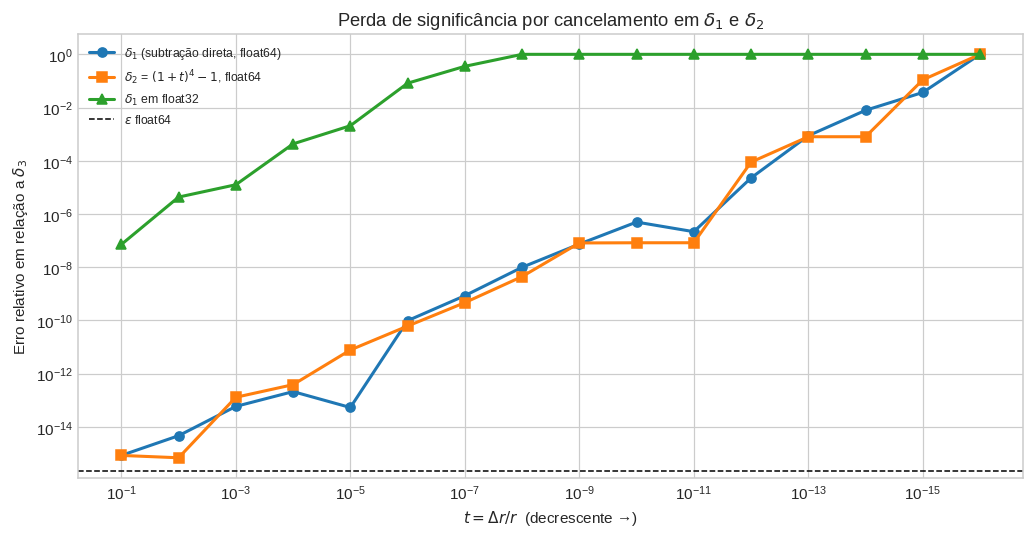

In [ ]:
# Cria a figura da perda de significância.
plt.figure(figsize=(9.5, 5))

# Desenha o erro relativo da forma delta 1 em precisão dupla.
plt.loglog(
    tabela_cancelamento["Δr/r"],
    tabela_cancelamento["erro rel. de δ1"].replace(0.0, np.nan),
    "o-",
    linewidth=2,
    label="$\\delta_1$ (subtração direta, float64)",
)

# Desenha o erro relativo da forma delta 2 em precisão dupla.
plt.loglog(
    tabela_cancelamento["Δr/r"],
    tabela_cancelamento["erro rel. de δ2"].replace(0.0, np.nan),
    "s-",
    linewidth=2,
    label="$\\delta_2$ = $(1+t)^4-1$, float64",
)

# Desenha o erro relativo da forma delta 1 em precisão simples.
plt.loglog(
    tabela_cancelamento["Δr/r"],
    tabela_cancelamento["erro rel. de δ1 (float32)"].replace(0.0, np.nan),
    "^-",
    linewidth=2,
    label="$\\delta_1$ em float32",
)

# Desenha a reta de referência do epsilon de máquina em precisão dupla.
plt.axhline(np.finfo(np.float64).eps, color="black", linestyle="--", linewidth=1.0,
            label="$\\varepsilon$ float64")

# Inverte o eixo horizontal para que t diminua da esquerda para a direita.
plt.gca().invert_xaxis()

# Identifica o eixo horizontal.
plt.xlabel("$t = \\Delta r / r$  (decrescente →)")

# Identifica o eixo vertical.
plt.ylabel("Erro relativo em relação a $\\delta_3$")

# Adiciona o título do gráfico.
plt.title("Perda de significância por cancelamento em $\\delta_1$ e $\\delta_2$")

# Exibe a legenda.
plt.legend(fontsize=8)

# Organiza o layout.
plt.tight_layout()

# Mostra a figura.
plt.show()

**Diagnóstico do cancelamento.** À medida que $t = \Delta r/r$ diminui:

- $\delta_3$ (Horner) mantém precisão total — o resultado é dominado pelo termo $4t$,
  calculado sem subtrações;
- $\delta_2$ perde algarismos porque $(1+t)^4$ se aproxima de 1, e a subtração
  $(\approx 1) - 1$ descarta os algarismos iniciais coincidentes;
- $\delta_1$ é a pior forma: subtrai $r_+^4$ de $r^4$, dois números que coincidem em
  quase todos os algarismos. O erro relativo cresce aproximadamente como
  $\varepsilon / t$ e, em `float64`, quando $t \lesssim 10^{-16}$, o resultado colapsa
  para **zero exato** — o computador "não vê" mais a perturbação.

Em `float32` o colapso acontece muito antes, por volta de $t \approx 10^{-7}$. Ou seja:
**um erro de fabricação de $5$ fm no raio do nanocateter é invisível em precisão simples**,
ainda que a matemática exata previsse uma variação de vazão de $4\times10^{-7}$.

### D.3 — Fenômeno físico

Ao reduzir a escala característica do canal, a razão superfície/volume cresce como
$1/r$: um cilindro de raio $r$ tem área lateral $2\pi r L$ e volume $\pi r^{2} L$, de modo
que a razão vale $2/r$. No nanocateter de 50 nm essa razão é aproximadamente 16 mil vezes
maior que no tubo de 0,80 mm da Parte C. Como consequência, uma fração cada vez maior do
fluido está próxima da parede, e os efeitos viscosos e de superfície — atrito, camada de
hidratação, escorregamento (*slip*), carga elétrica da parede e interações
eletroviscosas — deixam de ser correções marginais e passam a governar o escoamento. Ao
mesmo tempo, o número de Reynolds torna-se minúsculo e a inércia é irrelevante: o
escoamento é dominado por difusão de quantidade de movimento. Nesse regime, as hipóteses
de Hagen–Poiseuille (meio contínuo, fluido newtoniano, condição de não-escorregamento na
parede, perfil parabólico plenamente desenvolvido) tornam-se questionáveis, sobretudo
quando o raio se aproxima de poucas dezenas de diâmetros moleculares.

> **Precisão aritmética e validade do modelo são conceitos diferentes.** O cálculo em
> `float64` fornece $Q$ com dezesseis algarismos corretos *dentro do modelo adotado*;
> isso não diz nada sobre o modelo descrever a realidade nessa escala. Um resultado pode
> ser numericamente preciso e fisicamente inadequado ao mesmo tempo — e, no nanocateter,
> a incerteza do modelo é ordens de grandeza maior que a incerteza aritmética.

## 7. Parte E — quadro único de resultados (PNG)

A figura abaixo reúne, em um único PNG de **1760 × 1100 pixels** (acima do mínimo de
1600 × 1000 exigido), os cartões com os principais valores, a comparação entre
truncamento e arredondamento, os três tipos de erro, a sensibilidade de $Q$ ao raio, a
comparação entre `float32` e `float64` e a conclusão sobre o nanocateter.

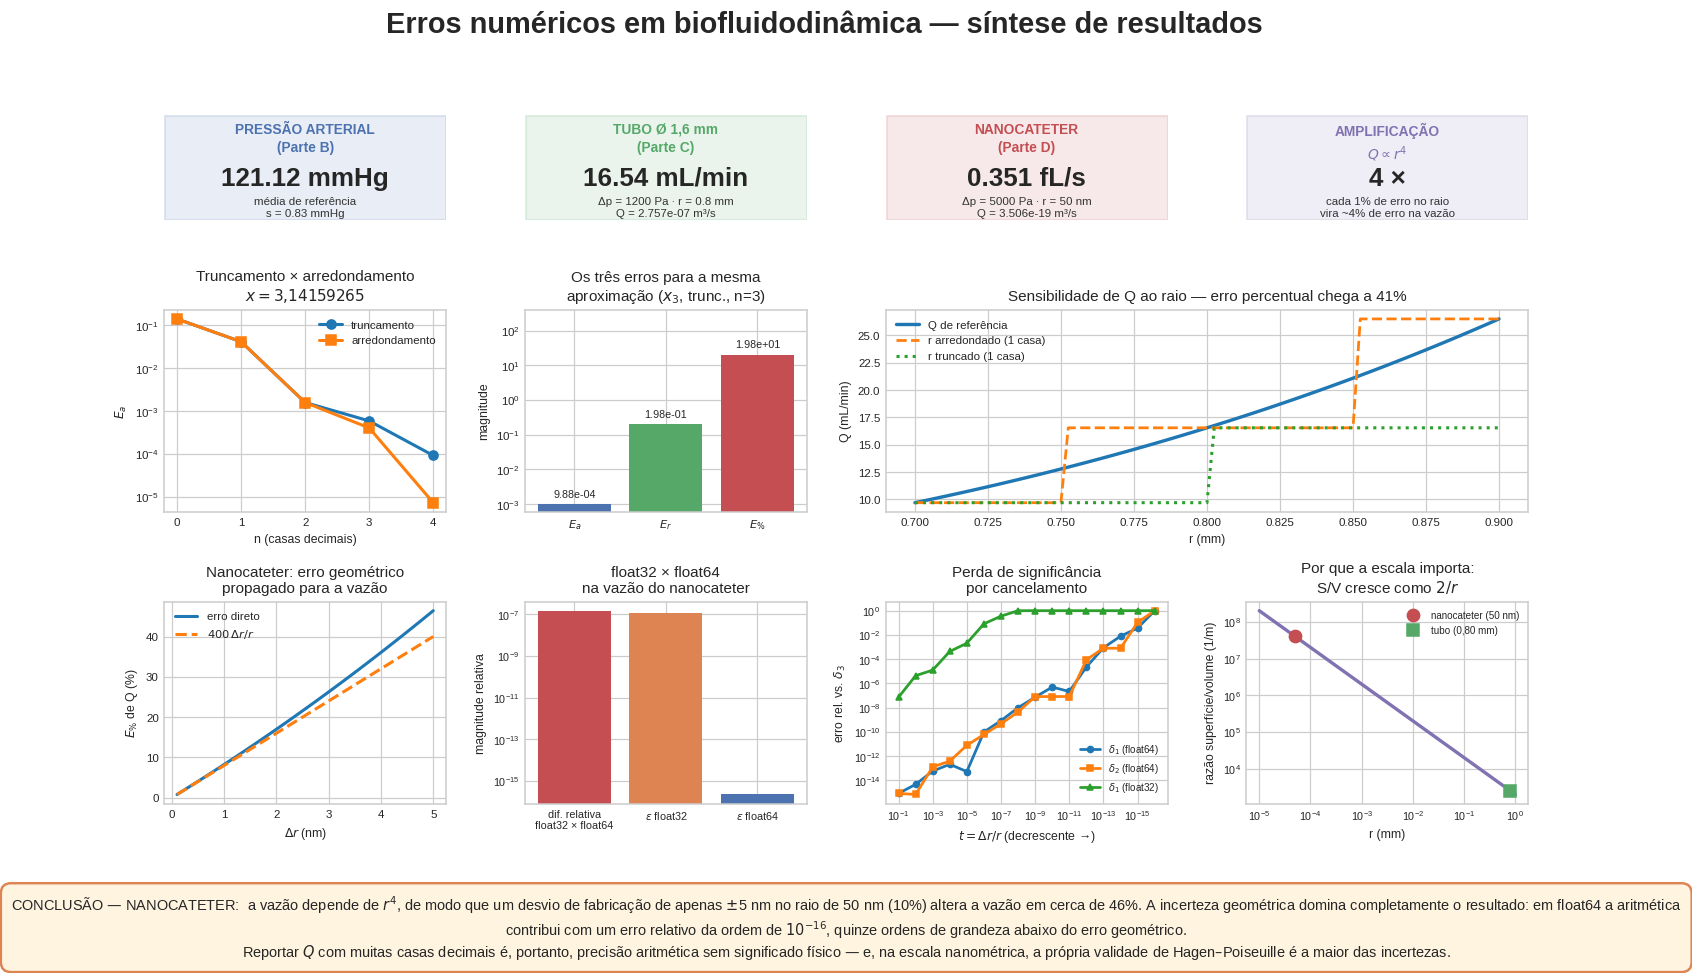

Arquivo 'quadro_sintese_calculo_numerico.png' salvo com 1920 x 1200 pixels.


In [ ]:
# Define o nome do arquivo PNG que será gerado.
nome_png = "quadro_sintese_calculo_numerico.png"

# Cria a figura com tamanho e resolução que garantem no mínimo 1600x1000 pixels.
figura = plt.figure(figsize=(16, 10), dpi=110)

# Define a grade de posicionamento dos painéis.
grade = gridspec.GridSpec(
    4, 4, figure=figura, height_ratios=[0.52, 1.0, 1.0, 0.34], hspace=0.62, wspace=0.28
)

# Adiciona o título geral do quadro.
figura.suptitle(
    "Erros numéricos em biofluidodinâmica — síntese de resultados",
    fontsize=19,
    fontweight="bold",
    y=0.975,
)

# Monta o conteúdo dos quatro cartões de destaque.
cartoes = [
    ("PRESSÃO ARTERIAL\n(Parte B)", f"{media_referencia:.2f} mmHg",
     f"média de referência\ns = {medidas.std(ddof=1):.2f} mmHg", "#4C72B0"),
    ("TUBO Ø 1,6 mm\n(Parte C)", f"{Q_ref_c * 1e6 * 60:.2f} mL/min",
     f"Δp = {dp_c:.0f} Pa · r = {r_mm} mm\nQ = {Q_ref_c:.3e} m³/s", "#55A868"),
    ("NANOCATETER\n(Parte D)", f"{Q_ref_nano * 1e18:.3f} fL/s",
     f"Δp = {dp_nano:.0f} Pa · r = 50 nm\nQ = {Q_ref_nano:.3e} m³/s", "#C44E52"),
    ("AMPLIFICAÇÃO\n$Q \\propto r^4$", "4 ×",
     "cada 1% de erro no raio\nvira ~4% de erro na vazão", "#8172B2"),
]

# Percorre os quatro cartões para desenhá-los na primeira linha da grade.
for coluna, (titulo, valor, rodape, cor) in enumerate(cartoes):
    # Cria o painel do cartão atual.
    eixo = figura.add_subplot(grade[0, coluna])

    # Remove os eixos, já que o cartão contém apenas texto.
    eixo.axis("off")

    # Desenha o retângulo de fundo do cartão.
    eixo.add_patch(
        plt.Rectangle((0, 0), 1, 1, transform=eixo.transAxes,
                      facecolor=cor, alpha=0.12, edgecolor=cor, linewidth=2)
    )

    # Escreve o título do cartão.
    eixo.text(0.5, 0.93, titulo, ha="center", va="top", fontsize=9,
              fontweight="bold", color=cor, linespacing=1.35,
              transform=eixo.transAxes)

    # Escreve o valor de destaque do cartão.
    eixo.text(0.5, 0.40, valor, ha="center", va="center", fontsize=17,
              fontweight="bold", transform=eixo.transAxes)

    # Escreve o rodapé explicativo do cartão.
    eixo.text(0.5, 0.12, rodape, ha="center", va="center", fontsize=7.5,
              color="#333333", linespacing=1.35, transform=eixo.transAxes)

# Cria o painel de comparação entre truncamento e arredondamento.
eixo_a = figura.add_subplot(grade[1, 0])

# Seleciona os dados da Parte A referentes ao primeiro valor.
recorte_a = tabela_parte_a[tabela_parte_a["valor"] == "x1 = 3,14159265"]

# Percorre os dois métodos para desenhar suas curvas.
for metodo, marcador in [("truncamento", "o"), ("arredondamento", "s")]:
    # Seleciona as linhas do método atual.
    sub = recorte_a[recorte_a["método"] == metodo]

    # Desenha a curva do erro absoluto.
    eixo_a.semilogy(sub["n (casas)"], sub["Ea"].replace(0.0, np.nan),
                    marker=marcador, linewidth=2, label=metodo)

# Configura os rótulos e o título do painel.
eixo_a.set_xlabel("n (casas decimais)", fontsize=8)
eixo_a.set_ylabel("$E_a$", fontsize=8)
eixo_a.set_title("Truncamento × arredondamento\n$x = 3{,}14159265$", fontsize=10)
eixo_a.set_xticks(casas_testadas)
eixo_a.tick_params(labelsize=7.5)
eixo_a.legend(fontsize=7.5)

# Cria o painel dos três tipos de erro.
eixo_b = figura.add_subplot(grade[1, 1])

# Seleciona a linha da Parte A correspondente a x3 truncado em duas casas.
linha_erro = tabela_parte_a[
    (tabela_parte_a["valor"] == "x3 = 0,00498765")
    & (tabela_parte_a["n (casas)"] == 3)
    & (tabela_parte_a["método"] == "truncamento")
].iloc[0]

# Desenha as barras dos três tipos de erro em escala logarítmica.
eixo_b.bar(
    ["$E_a$", "$E_r$", "$E_\\%$"],
    [linha_erro["Ea"], linha_erro["Er"], linha_erro["E% (%)"]],
    color=["#4C72B0", "#55A868", "#C44E52"],
)

# Aplica escala logarítmica ao eixo vertical.
eixo_b.set_yscale("log")

# Configura os rótulos e o título do painel.
eixo_b.set_ylabel("magnitude", fontsize=8)
eixo_b.set_title("Os três erros para a mesma\naproximação ($x_3$, trunc., n=3)", fontsize=10)
eixo_b.tick_params(labelsize=7.5)

# Amplia o limite superior para que os rótulos das barras não toquem a borda.
eixo_b.set_ylim(top=float(linha_erro["E% (%)"]) * 20)

# Escreve o valor numérico acima de cada barra.
for posicao, valor in enumerate([linha_erro["Ea"], linha_erro["Er"], linha_erro["E% (%)"]]):
    eixo_b.text(posicao, valor * 1.6, f"{valor:.2e}", ha="center", fontsize=7)

# Cria o painel da sensibilidade da vazão ao raio, ocupando duas colunas.
eixo_c = figura.add_subplot(grade[1, 2:])

# Desenha as três curvas de vazão da Parte C.2.
eixo_c.plot(raios_mm, Q_ref_vetor * 1e6 * 60, linewidth=2.2, label="Q de referência")
eixo_c.plot(raios_mm, Q_arred_vetor * 1e6 * 60, "--", linewidth=1.8, label="r arredondado (1 casa)")
eixo_c.plot(raios_mm, Q_trunc_vetor * 1e6 * 60, ":", linewidth=2.0, label="r truncado (1 casa)")

# Configura os rótulos e o título do painel.
eixo_c.set_xlabel("r (mm)", fontsize=8)
eixo_c.set_ylabel("Q (mL/min)", fontsize=8)
eixo_c.set_title(
    f"Sensibilidade de Q ao raio — erro percentual chega a {100 * er_trunc.max():.0f}%",
    fontsize=10,
)
eixo_c.tick_params(labelsize=7.5)
eixo_c.legend(fontsize=7.5)

# Cria o painel do erro percentual no nanocateter.
eixo_d = figura.add_subplot(grade[2, 0])

# Desenha o erro percentual exato e a estimativa linear.
eixo_d.plot(delta_r_nm, ep_max_nano, linewidth=2, label="erro direto")
eixo_d.plot(delta_r_nm, 100 * er_linear, "--", linewidth=2, label="$400\\,\\Delta r/r$")

# Configura os rótulos e o título do painel.
eixo_d.set_xlabel("$\\Delta r$ (nm)", fontsize=8)
eixo_d.set_ylabel("$E_\\%$ de Q (%)", fontsize=8)
eixo_d.set_title("Nanocateter: erro geométrico\npropagado para a vazão", fontsize=10)
eixo_d.tick_params(labelsize=7.5)
eixo_d.legend(fontsize=7.5)

# Cria o painel de comparação entre as precisões de ponto flutuante.
eixo_e = figura.add_subplot(grade[2, 1])

# Desenha as barras comparando a diferença observada com os epsilons de máquina.
eixo_e.bar(
    ["dif. relativa\nfloat32 × float64", "$\\varepsilon$ float32", "$\\varepsilon$ float64"],
    [dif_rel_precisao, float(np.finfo(np.float32).eps), float(np.finfo(np.float64).eps)],
    color=["#C44E52", "#DD8452", "#4C72B0"],
)

# Aplica escala logarítmica ao eixo vertical.
eixo_e.set_yscale("log")

# Configura os rótulos e o título do painel.
eixo_e.set_ylabel("magnitude relativa", fontsize=8)
eixo_e.set_title("float32 × float64\nna vazão do nanocateter", fontsize=10)
eixo_e.tick_params(labelsize=7)

# Cria o painel da perda de significância.
eixo_f = figura.add_subplot(grade[2, 2])

# Desenha as curvas de erro relativo das formas delta 1 e delta 2.
eixo_f.loglog(tabela_cancelamento["Δr/r"],
              tabela_cancelamento["erro rel. de δ1"].replace(0.0, np.nan),
              "o-", linewidth=1.8, markersize=4, label="$\\delta_1$ (float64)")
eixo_f.loglog(tabela_cancelamento["Δr/r"],
              tabela_cancelamento["erro rel. de δ2"].replace(0.0, np.nan),
              "s-", linewidth=1.8, markersize=4, label="$\\delta_2$ (float64)")
eixo_f.loglog(tabela_cancelamento["Δr/r"],
              tabela_cancelamento["erro rel. de δ1 (float32)"].replace(0.0, np.nan),
              "^-", linewidth=1.8, markersize=4, label="$\\delta_1$ (float32)")

# Inverte o eixo horizontal para acompanhar a redução de t.
eixo_f.invert_xaxis()

# Configura os rótulos e o título do painel.
eixo_f.set_xlabel("$t = \\Delta r/r$ (decrescente →)", fontsize=8)
eixo_f.set_ylabel("erro rel. vs. $\\delta_3$", fontsize=8)
eixo_f.set_title("Perda de significância\npor cancelamento", fontsize=10)
eixo_f.tick_params(labelsize=7)
eixo_f.legend(fontsize=6.5)

# Cria o painel do efeito de escala.
eixo_g = figura.add_subplot(grade[2, 3])

# Cria um vetor de raios em escala logarítmica, do nanômetro ao milímetro.
raios_escala = np.logspace(-8, -3, 200)

# Calcula a razão superfície/volume de um cilindro para cada raio.
razao_sv = 2.0 / raios_escala

# Desenha a curva da razão superfície/volume.
eixo_g.loglog(raios_escala * 1e3, razao_sv, linewidth=2.2, color="#8172B2")

# Marca o ponto correspondente ao nanocateter.
eixo_g.plot([r_nano * 1e3], [2.0 / r_nano], "o", color="#C44E52", markersize=8,
            label="nanocateter (50 nm)")

# Marca o ponto correspondente ao tubo da Parte C.
eixo_g.plot([r_mm], [2.0 / (r_mm * 1e-3)], "s", color="#55A868", markersize=8,
            label="tubo (0,80 mm)")

# Configura os rótulos e o título do painel.
eixo_g.set_xlabel("r (mm)", fontsize=8)
eixo_g.set_ylabel("razão superfície/volume (1/m)", fontsize=8)
eixo_g.set_title("Por que a escala importa:\nS/V cresce como $2/r$", fontsize=10)
eixo_g.tick_params(labelsize=7)
eixo_g.legend(fontsize=6.5)

# Cria o painel de conclusão, ocupando toda a largura da última linha.
eixo_conclusao = figura.add_subplot(grade[3, :])

# Remove os eixos do painel de texto.
eixo_conclusao.axis("off")

# Monta o texto da conclusão sobre o nanocateter.
texto_conclusao = (
    "CONCLUSÃO — NANOCATETER:  a vazão depende de $r^4$, de modo que um desvio de fabricação de apenas "
    f"$\\pm$5 nm no raio de 50 nm (10%) altera a vazão em cerca de {ep_max_nano[-1]:.0f}%. "
    "A incerteza geométrica domina completamente o resultado: em float64 a aritmética contribui com um erro relativo da ordem de "
    "$10^{-16}$, quinze ordens de grandeza abaixo do erro geométrico.\n"
    "Reportar $Q$ com muitas casas decimais é, portanto, precisão aritmética sem significado físico — e, na escala nanométrica, "
    "a própria validade de Hagen–Poiseuille é a maior das incertezas."
)

# Escreve o texto de conclusão dentro de uma caixa destacada.
eixo_conclusao.text(
    0.5, 0.5, texto_conclusao, ha="center", va="center", fontsize=9.5,
    transform=eixo_conclusao.transAxes, wrap=True,
    bbox=dict(boxstyle="round,pad=0.7", facecolor="#FFF4E0", edgecolor="#DD8452", linewidth=1.6),
)

# Salva o quadro-síntese em arquivo PNG.
figura.savefig(nome_png, dpi=120, facecolor="white")

# Mostra a figura na saída da célula.
plt.show()

# Reabre o arquivo salvo para confirmar as dimensões finais em pixels.
with Image.open(nome_png) as imagem_salva:
    print(f"Arquivo '{nome_png}' salvo com {imagem_salva.width} x {imagem_salva.height} pixels.")

## 8. GIF demonstrativo

O GIF possui 51 quadros e varre o raio do nanocateter de 45 a 55 nm. Cada quadro mostra a
seção transversal do canal, o raio e a vazão atuais, o erro percentual em relação a
$r = 50$ nm e a curva $Q \times r$ sendo construída progressivamente.

In [ ]:
# Define o nome do arquivo GIF que será gerado.
nome_gif = "nanocateter_sensibilidade.gif"

# Cria o vetor de raios do GIF, de 45 a 55 nm, com 51 quadros.
raios_gif_nm = np.linspace(45.0, 55.0, 51)

# Calcula a vazão correspondente a cada raio do GIF.
Q_gif = np.array([vazao_hp(r * 1e-9, dp_nano, mu_nano, L_nano) for r in raios_gif_nm])

# Cria uma lista para armazenar os quadros do GIF.
quadros = []

# Percorre cada raio para construir um quadro.
for indice, raio_atual in enumerate(raios_gif_nm):
    # Calcula a vazão do raio atual.
    Q_atual = Q_gif[indice]

    # Calcula os erros em relação ao raio de referência de 50 nm.
    ea_gif, er_gif, ep_gif = calcular_erros(Q_ref_nano, Q_atual)

    # Determina o sinal do desvio para exibição no rótulo.
    sinal = "+" if Q_atual >= Q_ref_nano else "-"

    # Cria a figura do quadro com dois painéis.
    figura_gif, (painel_esq, painel_dir) = plt.subplots(1, 2, figsize=(10, 4.6), dpi=100)

    # Desenha o círculo de referência de 50 nm no painel da esquerda.
    painel_esq.add_patch(
        plt.Circle((0, 0), 50.0, fill=False, linestyle="--", edgecolor="gray", linewidth=1.5)
    )

    # Desenha a seção transversal correspondente ao raio atual.
    painel_esq.add_patch(
        plt.Circle((0, 0), raio_atual, facecolor="#4C72B0", alpha=0.45,
                   edgecolor="#20344F", linewidth=2.2)
    )

    # Desenha a seta que indica o raio atual.
    painel_esq.annotate(
        "", xy=(raio_atual, 0), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="#20344F", linewidth=2),
    )

    # Escreve o valor do raio ao lado da seta.
    painel_esq.text(raio_atual / 2, 3.0, f"r = {raio_atual:.1f} nm",
                    ha="center", fontsize=10, fontweight="bold")

    # Define limites fixos para que o círculo não mude de escala entre quadros.
    painel_esq.set_xlim(-62, 62)
    painel_esq.set_ylim(-62, 62)

    # Mantém a proporção entre os eixos para que o círculo não fique deformado.
    painel_esq.set_aspect("equal")

    # Configura os rótulos do painel da esquerda.
    painel_esq.set_xlabel("x (nm)", fontsize=9)
    painel_esq.set_ylabel("y (nm)", fontsize=9)
    painel_esq.set_title("Seção transversal do nanocateter", fontsize=11)

    # Escreve o quadro de informações numéricas.
    painel_esq.text(
        -58, -56,
        f"Q = {Q_atual * 1e18:.4f} fL/s\n"
        f"$E_\\%$ vs. r = 50 nm: {sinal}{ep_gif:.1f}%",
        fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#FFF4E0", edgecolor="#DD8452"),
    )

    # Desenha a curva completa de referência, em tom claro, no painel da direita.
    painel_dir.plot(raios_gif_nm, Q_gif * 1e18, color="lightgray", linewidth=1.2)

    # Desenha a parte da curva já percorrida.
    painel_dir.plot(raios_gif_nm[: indice + 1], Q_gif[: indice + 1] * 1e18,
                    color="#C44E52", linewidth=2.6)

    # Marca o ponto atual sobre a curva.
    painel_dir.plot([raio_atual], [Q_atual * 1e18], "o", color="#C44E52", markersize=9)

    # Marca o ponto de referência de 50 nm.
    painel_dir.plot([50.0], [Q_ref_nano * 1e18], "s", color="black", markersize=7)

    # Desenha as linhas guia do ponto de referência.
    painel_dir.axvline(50.0, color="black", linestyle="--", linewidth=0.9)
    painel_dir.axhline(Q_ref_nano * 1e18, color="black", linestyle="--", linewidth=0.9)

    # Define limites fixos para o painel da direita.
    painel_dir.set_xlim(44, 56)
    painel_dir.set_ylim(Q_gif.min() * 1e18 * 0.92, Q_gif.max() * 1e18 * 1.06)

    # Configura os rótulos do painel da direita.
    painel_dir.set_xlabel("r (nm)", fontsize=9)
    painel_dir.set_ylabel("Q (fL/s)", fontsize=9)
    painel_dir.set_title("Curva $Q \\times r$  ($Q \\propto r^4$)", fontsize=11)

    # Adiciona o título geral do quadro.
    figura_gif.suptitle("Sensibilidade da vazão ao raio do nanocateter", fontsize=12.5)

    # Organiza o layout do quadro.
    figura_gif.tight_layout()

    # Cria um buffer em memória para receber a imagem do quadro.
    buffer = io.BytesIO()

    # Salva a figura no buffer em formato PNG.
    figura_gif.savefig(buffer, format="png", facecolor="white")

    # Fecha a figura para liberar memória.
    plt.close(figura_gif)

    # Retorna ao início do buffer antes de ler a imagem.
    buffer.seek(0)

    # Abre a imagem com o Pillow, converte para RGB e guarda na lista de quadros.
    quadros.append(Image.open(buffer).convert("RGB"))

# Salva a sequência de quadros como um GIF em laço infinito.
quadros[0].save(
    nome_gif,
    save_all=True,
    append_images=quadros[1:],
    duration=110,
    loop=0,
    optimize=True,
)

# Confirma a geração do arquivo e informa suas características.
print(f"GIF '{nome_gif}' gerado com {len(quadros)} quadros de "
      f"{quadros[0].width} x {quadros[0].height} pixels.")

GIF 'nanocateter_sensibilidade.gif' gerado com 51 quadros de 1000 x 459 pixels.


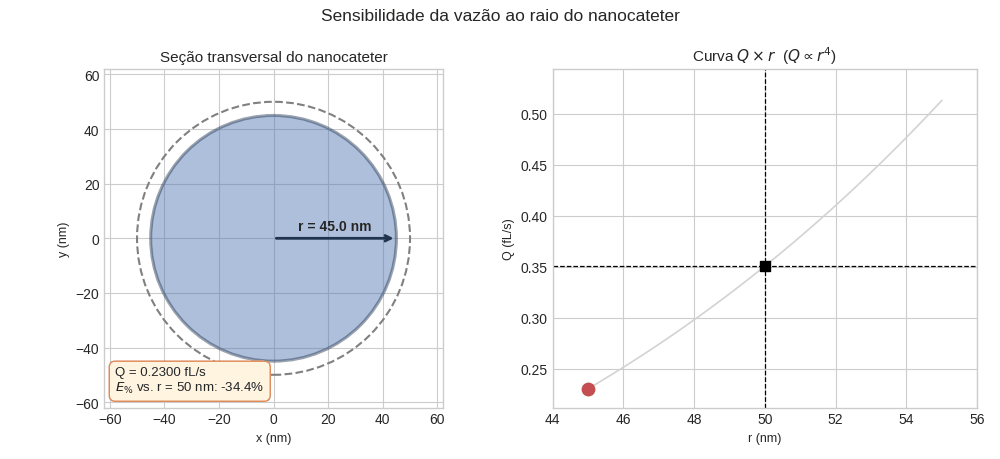

In [ ]:
# Exibe o GIF na saída da célula quando o notebook roda no Colab.
try:
    # Importa a classe de exibição de imagens do IPython.
    from IPython.display import Image as ImagemIPython

    # Exibe o arquivo GIF gerado.
    display(ImagemIPython(filename=nome_gif))
except Exception as erro:
    # Informa o motivo caso a exibição não seja possível.
    print("Não foi possível exibir o GIF nesta saída:", erro)

## 9. Respostas às questões e conclusão

### Respostas diretas

**A.5 — Arredondar sempre gera erro menor ou igual ao truncamento?**
Sim, uma vez que fdo $n$, o arredondamento escolhe o ponto mais próximo da malha de espaçamento
$10^{-n}$ e o truncamento escolhe o ponto imediatamente inferior; logo
$E_a^{\text{arred}} \le 10^{-n}/2 \le E_a^{\text{trunc}}$. A verificação numérica
confirmou a desigualdade nos quinze casos da Parte A. Além disso, o truncamento é
**enviesado** (erra sempre no mesmo sentido para valores positivos), enquanto o
arredondamento produz erros de sinais alternados que tendem a se cancelar em somas.

**B.3 — A representação inteira preserva média e variabilidade?**
A média é razoavelmente preservada pelo arredondamento (erro da ordem de $10^{-2}\%$),
mas não pelo truncamento, cujo viés se acumula. A variabilidade **não** é preservada por
nenhum dos dois: o passo de discretização de 1 mmHg é comparável à dispersão da amostra
(amplitude de 2,6 mmHg), então o desvio-padrão muda de forma perceptível e o histograma
colapsa dez valores distintos em poucas classes.

**C.3 — Por que o erro no raio é amplificado na vazão?**
Porque $Q \propto r^{4}$. Diferenciando, $\Delta Q/Q \approx 4\,\Delta r/r$: o expoente
aparece diretamente como fator multiplicativo do erro relativo. Um erro de 6% no raio
produz cerca de 25% de erro na vazão.

**D.1 — Erro direto vs. aproximação linear.**
A forma exata é $(1+t)^4 - 1 = 4t + 6t^2 + 4t^3 + t^4$. A aproximação linear retém apenas
$4t$ e portanto **subestima** o erro; a subestimação é desprezível para $t \lesssim 0{,}01$
e chega a cerca de 14% para $t = 0{,}1$ ($\Delta r = 5$ nm).

**D.2 — Perda de significância.**
$\delta_1$ subtrai duas vazões quase idênticas e perde algarismos proporcionalmente a
$\varepsilon/t$; em `float64` o resultado colapsa para zero quando $t \lesssim 10^{-16}$,
e em `float32` já por volta de $t \approx 10^{-7}$. A forma expandida por Horner,
$\delta_3 = t(4 + t(6 + t(4+t)))$, elimina a subtração crítica e permanece precisa em
toda a faixa.

---

### Conclusão

Esta atividade mostra que o erro de um resultado numérico raramente nasce da aritmética
do computador: ele nasce da representação dos **dados de entrada** e da forma como a
**estrutura do modelo** os amplifica. Na Parte A, arredondamento e truncamento diferem
por um fator de até dois, com o truncamento sistematicamente enviesado. Na Parte B, esse
viés se acumula na média enquanto a discretização inteira destrói a variabilidade de uma
amostra de baixa dispersão. Nas Partes C e D, a dependência $Q \propto r^{4}$ multiplica
por quatro qualquer erro relativo do raio, de modo que $\pm5$ nm em um nanocateter de
50 nm produzem cerca de 46% de variação na vazão — enquanto a aritmética em `float64`
contribui com um erro quinze ordens de grandeza menor. A escolha entre `float32` e
`float64`, a ordem das operações e a formulação algébrica (evitando subtrair números
próximos) importam, mas o que domina a incerteza é a qualidade dos dados e a validade
das hipóteses físicas. Precisão aritmética e validade do modelo são, de fato, conceitos
diferentes: na escala nanométrica, onde a razão superfície/volume torna os efeitos de
parede dominantes, um resultado com dezesseis algarismos corretos pode continuar sendo
fisicamente inadequado.